# **1. Perkenalan Dataset**


**Facies Classification from Wireline Logs**

Dataset Fasies ini berasal dari dataset "Facies Classification" yang berasal dari
Hugoton dan Panoma Fields (Council Grove gas reservoir), Kansas, Amerika Serikat.
Dataset ini digunakan dalam SEG 2016 Machine Learning Contest (Dubois et al., 2007;
Hall, 2016). Tujuannya adalah memprediksi **lithofacies** (jenis lapisan batuan)
berdasarkan pembacaan log wireline, sebagai pengganti deskripsi core batuan fisik 
yang mahal dan memakan waktu.

Tujuh fitur prediktor terdiri dari lima log wireline asli dan dua variabel constraint 
geologis berikut:
- GR — gamma ray
- ILD_log10 — resistivity
- DeltaPHI — porosity diff
- PHIND — avg porosity
- PE — photoelectric effect
- NM_M — nonmarine/marine
- RELPOS — posisi relatif (constraint geologis)

Targetnya adalah penentuan Facies dalam sembilan kelas lithofacies berikut:

| Kode | Label | Deskripsi |
|---|---|---|
| 1 | SS | Nonmarine sandstone |
| 2 | CSiS | Nonmarine coarse siltstone |
| 3 | FSiS | Nonmarine fine siltstone |
| 4 | SiSh | Marine siltstone & shale |
| 5 | MS | Mudstone |
| 6 | WS | Wackestone |
| 7 | D | Dolomite |
| 8 | PS | Packstone-grainstone |
| 9 | BS | Phylloid-algal bafflestone |

Notebook ini berisi tahapan eksperimen manual: data loading, EDA, dan preprocessing.

**Sumber Dataset**:

- Sumber: [seg/2016-ml-contest](https://github.com/seg/2016-ml-contest)
- Dataset:  [Training CSV Data](https://raw.githubusercontent.com/seg/2016-ml-contest/master/training_data.csv)
- Referensi: Dubois et al. (2007); Hall, B. (2016) — *Facies classification
using machine learning*, The Leading Edge.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
print('Setup selesai!')

Setup selesai!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
from pathlib import Path
import urllib.request

url = "https://raw.githubusercontent.com/seg/2016-ml-contest/master/training_data.csv"
csv_path = "../facies_raw.csv"

print("📥 Download Dataset Fasies...")
urllib.request.urlretrieve(url, csv_path)
print(f"Selesai! File sudah tersimpan di '{csv_path}'.")

📥 Download Dataset Fasies...
Selesai! File sudah tersimpan di '../facies_raw.csv'.


In [3]:
df = pd.read_csv(csv_path)

print(f'Shape dataset: {df.shape}')
df.head()

Shape dataset: (3232, 11)


,Facies,Formation,Well Name,Depth,GR,ILD_log10,DeltaPHI,PHIND,PE,NM_M,RELPOS
0,3,A1 SH,SHRIMPLIN,2793.0,77.45,0.664,9.9,11.915,4.6,1,1.000
1,3,A1 SH,SHRIMPLIN,2793.5,78.26,0.661,14.2,12.565,4.1,1,0.979
2,3,A1 SH,SHRIMPLIN,2794.0,79.05,0.658,14.8,13.050,3.6,1,0.957
3,3,A1 SH,SHRIMPLIN,2794.5,86.10,0.655,13.9,13.115,3.5,1,0.936
4,3,A1 SH,SHRIMPLIN,2795.0,74.58,0.647,13.5,13.300,3.4,1,0.915


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3232 entries, 0 to 3231
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Facies     3232 non-null   int64  
 1   Formation  3232 non-null   object 
 2   Well Name  3232 non-null   object 
 3   Depth      3232 non-null   float64
 4   GR         3232 non-null   float64
 5   ILD_log10  3232 non-null   float64
 6   DeltaPHI   3232 non-null   float64
 7   PHIND      3232 non-null   float64
 8   PE         3232 non-null   float64
 9   NM_M       3232 non-null   int64  
 10  RELPOS     3232 non-null   float64
dtypes: float64(7), int64(2), object(2)
memory usage: 277.9+ KB


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [5]:
# Eksplorasi statistik deskriptif
df.describe()

,Facies,Depth,GR,ILD_log10,DeltaPHI,PHIND,PE,NM_M,RELPOS
count,3232.000000,3232.000000,3232.000000,3232.000000,3232.000000,3232.000000,3232.000000,3232.000000,3232.000000
mean,4.422030,2875.824567,66.135769,0.642719,3.559642,13.483213,3.725014,1.498453,0.520287
std,2.504243,131.006274,30.854826,0.241845,5.228948,7.698980,0.896152,0.500075,0.286792
min,1.000000,2573.500000,13.250000,-0.025949,-21.832000,0.550000,0.200000,1.000000,0.010000
25%,2.000000,2791.000000,46.918750,0.492750,1.163750,8.346750,3.100000,1.000000,0.273000
50%,4.000000,2893.500000,65.721500,0.624437,3.500000,12.150000,3.551500,1.000000,0.526000
75%,6.000000,2980.000000,79.626250,0.812735,6.432500,16.453750,4.300000,2.000000,0.767250
max,9.000000,3122.500000,361.150000,1.480000,18.600000,84.400000,8.094000,2.000000,1.000000


In [6]:
# Cek missing values
print('Missing values per kolom:')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')
print('Catatan: versi dataset resmi SEG ini sudah bersih dari missing value,')

Missing values per kolom:
Facies       0
Formation    0
Well Name    0
Depth        0
GR           0
ILD_log10    0
DeltaPHI     0
PHIND        0
PE           0
NM_M         0
RELPOS       0
dtype: int64

Total missing: 0
Catatan: versi dataset resmi SEG ini sudah bersih dari missing value,


In [7]:
# Cek duplikat
print(f'Jumlah baris duplikat: {df.duplicated().sum()}')

# Cek sumur dan formasi
print(f'\nJumlah sumur (Well Name): {df["Well Name"].nunique()}')
print(df['Well Name'].unique())
print(f'\nJumlah formasi (Formation): {df["Formation"].nunique()}')
print(df['Formation'].unique())

Jumlah baris duplikat: 1

Jumlah sumur (Well Name): 8
['SHRIMPLIN' 'SHANKLE' 'LUKE G U' 'CROSS H CATTLE' 'NOLAN' 'Recruit F9'
 'NEWBY' 'CHURCHMAN BIBLE']

Jumlah formasi (Formation): 14
['A1 SH' 'A1 LM' 'B1 SH' 'B1 LM' 'B2 SH' 'B2 LM' 'B3 SH' 'B3 LM' 'B4 SH'
 'B4 LM' 'B5 SH' 'B5 LM' 'C SH' 'C LM']


In [8]:
# Mapping kode Facies ke nama lithofacies (referensi: Dubois et al., 2007)
facies_labels = ['SS', 'CSiS', 'FSiS', 'SiSh', 'MS', 'WS', 'D', 'PS', 'BS']
facies_names = {
    1: 'Nonmarine sandstone', 2: 'Nonmarine coarse siltstone',
    3: 'Nonmarine fine siltstone', 4: 'Marine siltstone & shale',
    5: 'Mudstone', 6: 'Wackestone', 7: 'Dolomite',
    8: 'Packstone-grainstone', 9: 'Phylloid-algal bafflestone'
}

df['FaciesLabel'] = df['Facies'].map(lambda x: facies_labels[x-1])
print('Distribusi kelas Facies:')

facies_dist = df['Facies'].value_counts().sort_index()
for code, count in facies_dist.items():
    print(f'  Facies {code} ({facies_labels[code-1]:5s} - {facies_names[code]:28s}): {count:4d} ({count/len(df)*100:.1f}%)')

Distribusi kelas Facies:
  Facies 1 (SS    - Nonmarine sandstone         ):  259 (8.0%)
  Facies 2 (CSiS  - Nonmarine coarse siltstone  ):  738 (22.8%)
  Facies 3 (FSiS  - Nonmarine fine siltstone    ):  615 (19.0%)
  Facies 4 (SiSh  - Marine siltstone & shale    ):  184 (5.7%)
  Facies 5 (MS    - Mudstone                    ):  217 (6.7%)
  Facies 6 (WS    - Wackestone                  ):  462 (14.3%)
  Facies 7 (D     - Dolomite                    ):   98 (3.0%)
  Facies 8 (PS    - Packstone-grainstone        ):  498 (15.4%)
  Facies 9 (BS    - Phylloid-algal bafflestone  ):  161 (5.0%)


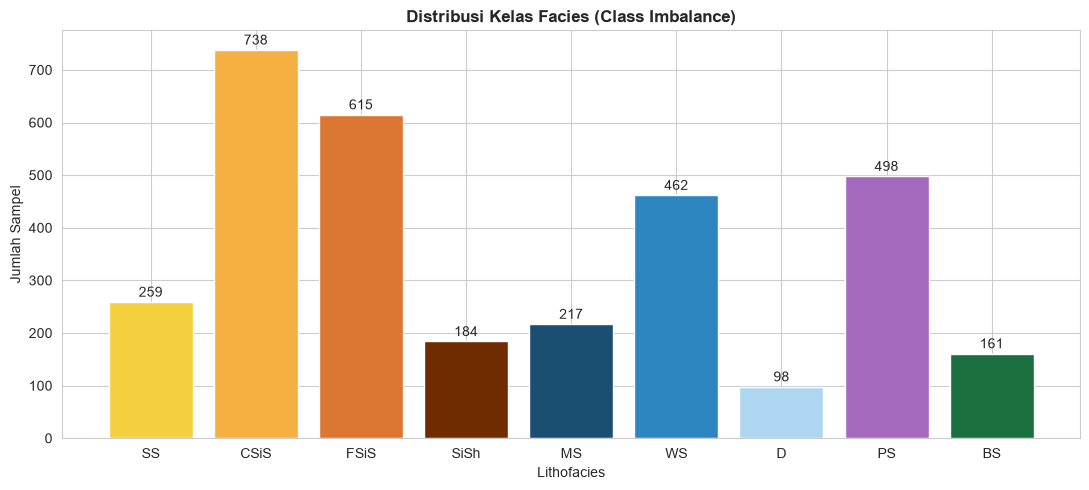

Rasio imbalance (kelas terbesar/terkecil): 7.5x
Kelas mayoritas: CSiS (738 sampel)
Kelas minoritas: D (98 sampel)


In [9]:
# Visualisasi distribusi kelas untuk menunjukkan ada class imbalance
facies_color_map = {1:'#F4D03F', 2:'#F5B041', 3:'#DC7633', 4:'#6E2C00', 5:'#1B4F72',
                    6:'#2E86C1', 7:'#AED6F1', 8:'#A569BD', 9:'#196F3D'}
colors_list = [facies_color_map[i] for i in facies_dist.index]

plt.figure(figsize=(11, 5))
bars = plt.bar([facies_labels[i-1] for i in facies_dist.index], facies_dist.values, color=colors_list)
plt.title('Distribusi Kelas Facies (Class Imbalance)', fontweight='bold')
plt.xlabel('Lithofacies')
plt.ylabel('Jumlah Sampel')
for bar, val in zip(bars, facies_dist.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 10, str(val), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('eda_facies_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

imbalance_ratio = facies_dist.max() / facies_dist.min()
print(f'Rasio imbalance (kelas terbesar/terkecil): {imbalance_ratio:.1f}x')
print(f'Kelas mayoritas: {facies_labels[facies_dist.idxmax()-1]} ({facies_dist.max()} sampel)')
print(f'Kelas minoritas: {facies_labels[facies_dist.idxmin()-1]} ({facies_dist.min()} sampel)')

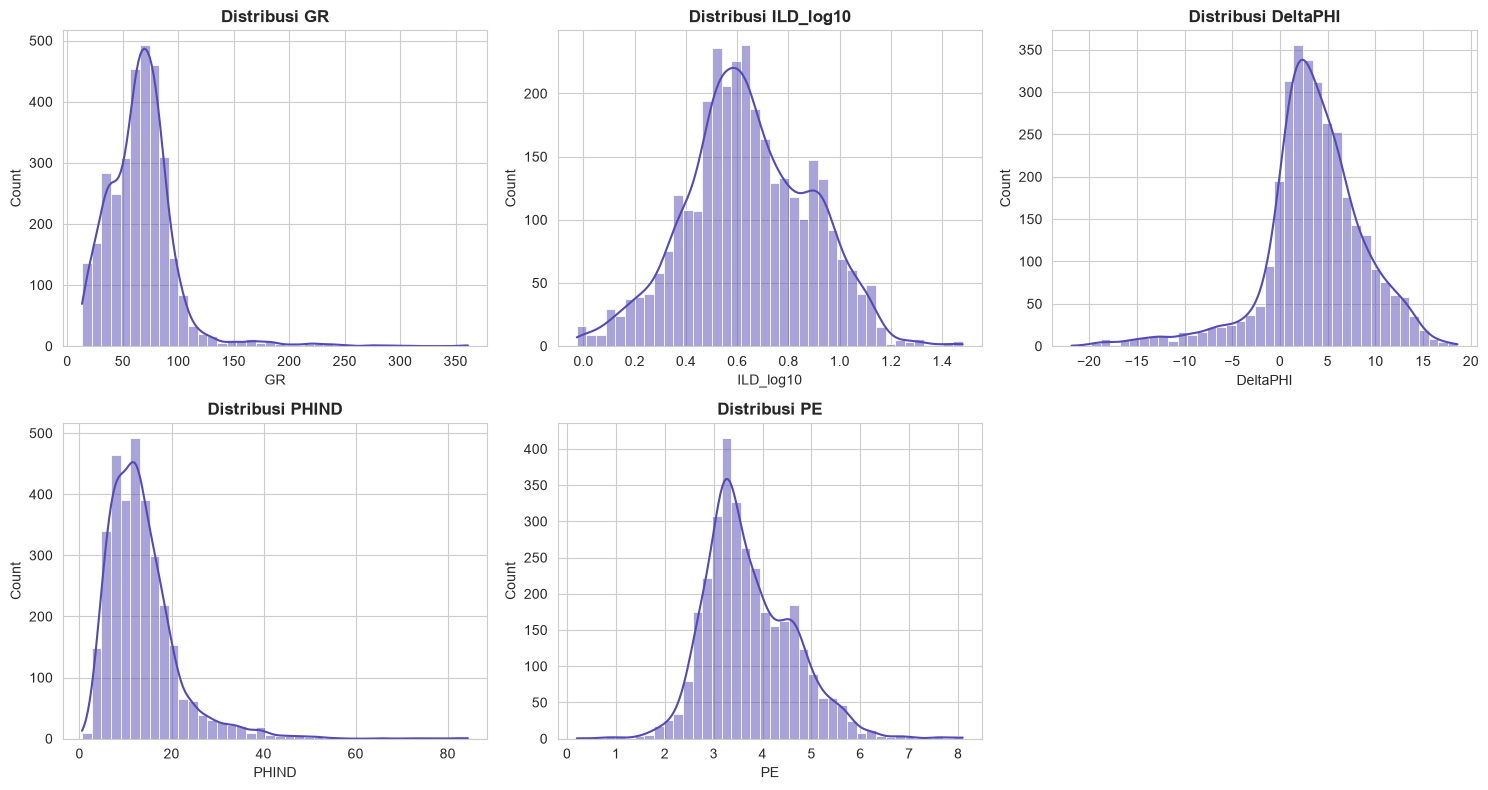

In [10]:
# Distribusi log curve numerik
log_curves = ['GR', 'ILD_log10', 'DeltaPHI', 'PHIND', 'PE']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(log_curves):
    sns.histplot(df[col], bins=40, kde=True, ax=axes[i], color='#534AB7')
    axes[i].set_title(f'Distribusi {col}', fontweight='bold')
axes[5].axis('off')

plt.tight_layout()
plt.savefig('eda_log_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

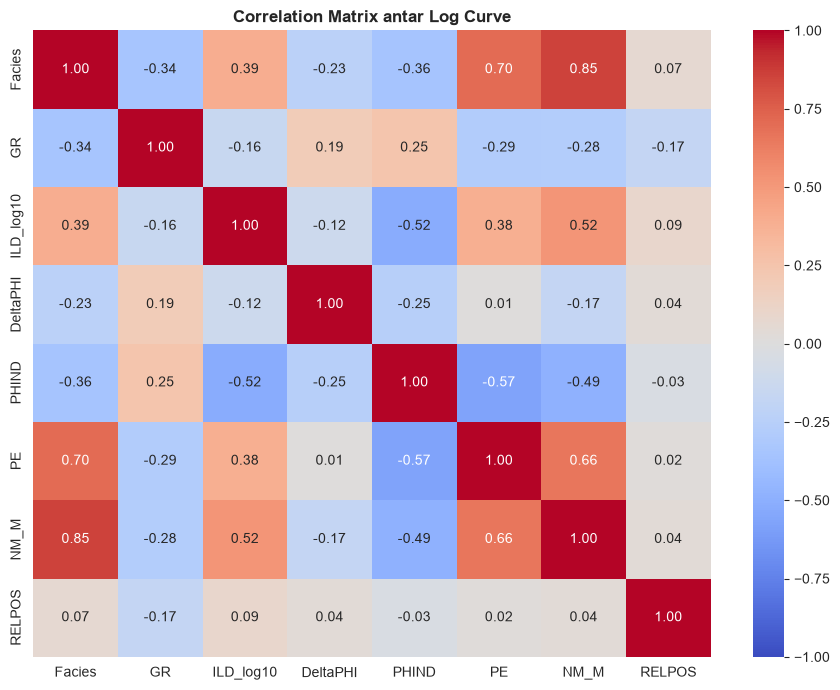

In [11]:
# Correlation matrix antar log curve
plt.figure(figsize=(9, 7))
corr_cols = ['Facies', 'GR', 'ILD_log10', 'DeltaPHI', 'PHIND', 'PE', 'NM_M', 'RELPOS']
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Matrix antar Log Curve', fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

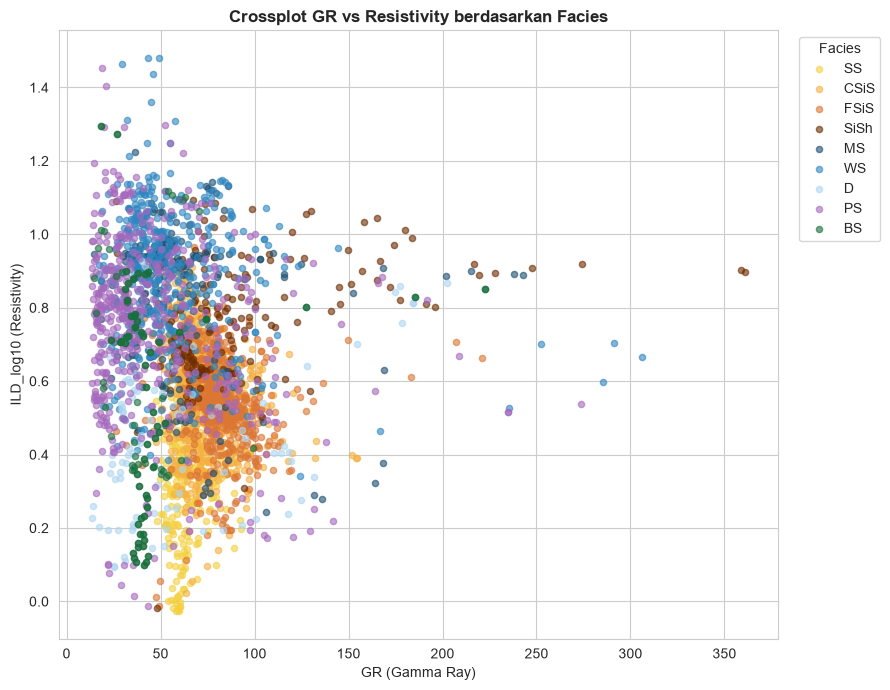

In [12]:
# Crossplot petrofisika: GR vs ILD_log10, diwarnai berdasarkan Facies
plt.figure(figsize=(9, 7))
for code in sorted(df['Facies'].unique()):
    subset = df[df['Facies'] == code]
    plt.scatter(subset['GR'], subset['ILD_log10'], label=facies_labels[code-1],
               color=facies_color_map[code], alpha=0.6, s=20)
plt.xlabel('GR (Gamma Ray)')
plt.ylabel('ILD_log10 (Resistivity)')
plt.title('Crossplot GR vs Resistivity berdasarkan Facies', fontweight='bold')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Facies')
plt.tight_layout()
plt.savefig('eda_crossplot_facies.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
df.head()

,Facies,Formation,Well Name,Depth,GR,ILD_log10,DeltaPHI,PHIND,PE,NM_M,RELPOS,FaciesLabel
0,3,A1 SH,SHRIMPLIN,2793.0,77.45,0.664,9.9,11.915,4.6,1,1.000,FSiS
1,3,A1 SH,SHRIMPLIN,2793.5,78.26,0.661,14.2,12.565,4.1,1,0.979,FSiS
2,3,A1 SH,SHRIMPLIN,2794.0,79.05,0.658,14.8,13.050,3.6,1,0.957,FSiS
3,3,A1 SH,SHRIMPLIN,2794.5,86.10,0.655,13.9,13.115,3.5,1,0.936,FSiS
4,3,A1 SH,SHRIMPLIN,2795.0,74.58,0.647,13.5,13.300,3.4,1,0.915,FSiS


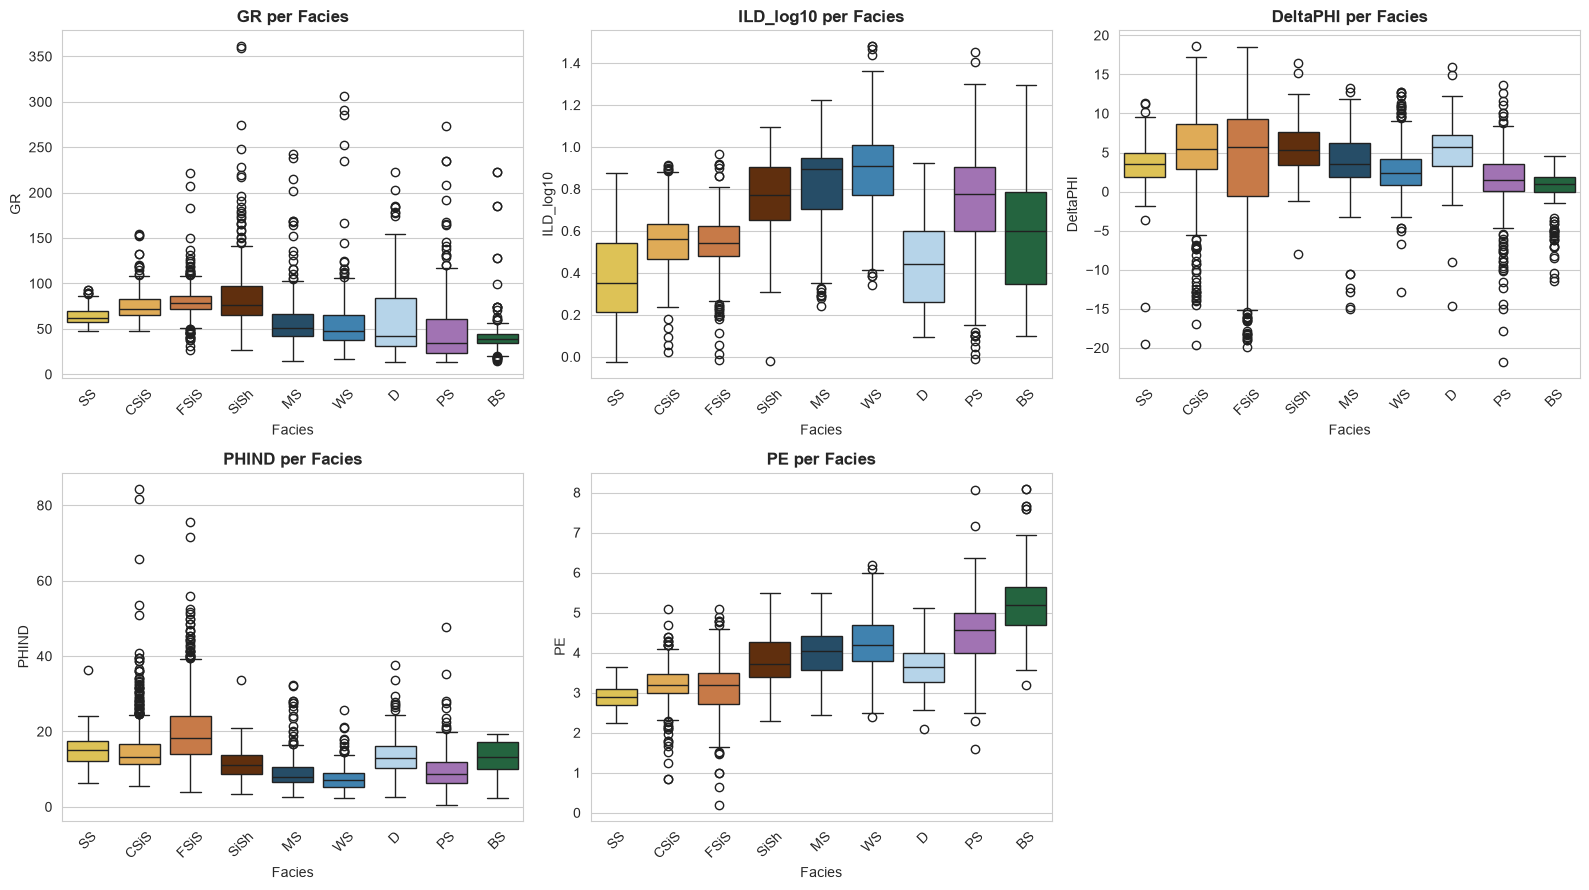

In [14]:
# Boxplot log curve per facies untuk melihat separabilitas kelas
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
facies_color_map = {str(key): value for key, value in facies_color_map.items()}

for i, col in enumerate(log_curves):
    sns.boxplot(data=df, x='Facies', y=col, ax=axes[i], palette=facies_color_map)
    axes[i].set_title(f'{col} per Facies', fontweight='bold')
    axes[i].set_xticklabels(facies_labels, rotation=45)
axes[5].axis('off')

plt.tight_layout()
plt.savefig('eda_boxplot_per_facies.png', dpi=150, bbox_inches='tight')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

## 5.1 Drop Kolom Bantuan EDA

In [15]:
# Drop kolom 'FaciesLabel' yang hanya digunakan untuk EDA, bukan untuk training
df = df.drop(columns=['FaciesLabel'])
print(f'Shape setelah drop kolom EDA: {df.shape}')

Shape setelah drop kolom EDA: (3232, 11)


## 5.2 Handling Missing Values (Defensive Check)

In [16]:
# Dataset ini sudah bersih, tapi kita tetap terapkan imputasi defensif (dengan Median)
# agar pipeline tetap valid apabila digunakan pada data baru yang punya missing value
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print(f'Missing values setelah imputasi: {df.isnull().sum().sum()}')

Missing values setelah imputasi: 0


## 5.3 Feature Encoding

In [17]:
categorical_cols = ['Formation', 'Well Name']
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le
    print(f'{col}: {len(le.classes_)} kategori unik di-encode')

df.head()

Formation: 14 kategori unik di-encode
Well Name: 8 kategori unik di-encode


,Facies,Formation,Well Name,Depth,GR,ILD_log10,DeltaPHI,PHIND,PE,NM_M,RELPOS
0,3,1,7,2793.0,77.45,0.664,9.9,11.915,4.6,1,1.000
1,3,1,7,2793.5,78.26,0.661,14.2,12.565,4.1,1,0.979
2,3,1,7,2794.0,79.05,0.658,14.8,13.050,3.6,1,0.957
3,3,1,7,2794.5,86.10,0.655,13.9,13.115,3.5,1,0.936
4,3,1,7,2795.0,74.58,0.647,13.5,13.300,3.4,1,0.915


## 5.4 Handling Outlier

In [18]:
# Cek dan cap outlier pada log curve numerik menggunakan IQR
numerical_cols = ['GR', 'ILD_log10', 'DeltaPHI', 'PHIND', 'PE']

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    print(f'{col}: {n_outliers} outlier di-cap (IQR method)')

GR: 83 outlier di-cap (IQR method)
ILD_log10: 29 outlier di-cap (IQR method)
DeltaPHI: 175 outlier di-cap (IQR method)
PHIND: 147 outlier di-cap (IQR method)
PE: 39 outlier di-cap (IQR method)


## 5.5 Feature Scaling

In [19]:
scale_cols = ['Depth', 'GR', 'ILD_log10', 'DeltaPHI', 'PHIND', 'PE']
scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

df.describe()

,Facies,Formation,Well Name,Depth,GR,ILD_log10,DeltaPHI,PHIND,PE,NM_M,RELPOS
count,3232.000000,3232.000000,3232.000000,3.232000e+03,3.232000e+03,3.232000e+03,3.232000e+03,3.232000e+03,3.232000e+03,3232.000000,3232.000000
mean,4.422030,6.426671,3.342512,4.221046e-16,1.934646e-16,1.846708e-16,-1.758769e-17,1.099231e-16,-2.198461e-16,1.498453,0.520287
std,2.504243,4.676493,2.359374,1.000155e+00,1.000155e+00,1.000155e+00,1.000155e+00,1.000155e+00,1.000155e+00,0.500075,0.286792
min,1.000000,0.000000,0.000000,-2.308068e+00,-2.074775e+00,-2.618421e+00,-2.290286e+00,-2.008336e+00,-2.780495e+00,1.000000,0.010000
25%,2.000000,2.000000,1.000000,-6.475850e-01,-7.157715e-01,-6.226747e-01,-5.649178e-01,-7.579314e-01,-7.118435e-01,1.000000,0.273000
50%,4.000000,7.000000,3.000000,1.349414e-01,4.318163e-02,-7.512021e-02,-5.488028e-02,-1.479846e-01,-1.929568e-01,1.000000,0.526000
75%,6.000000,11.000000,6.000000,7.953173e-01,6.044322e-01,7.078230e-01,5.853273e-01,5.422300e-01,6.672574e-01,2.000000,0.767250
max,9.000000,13.000000,7.000000,1.883220e+00,2.584738e+00,2.703569e+00,2.310695e+00,2.492472e+00,2.735909e+00,2.000000,1.000000


## 5.6 Verifikasi Akhir

In [20]:
print('=== Verifikasi Dataset Hasil Preprocessing ===')
print(f'Shape          : {df.shape}')
print(f'Missing values : {df.isnull().sum().sum()}')
print(f'Duplikat       : {df.duplicated().sum()}')
print(f'\nKolom akhir  : {df.columns.tolist()}')
print(f'\nDistribusi target (Facies):')
print(df['Facies'].value_counts(normalize=True).sort_index().map('{:.1%}'.format))
df.head()

=== Verifikasi Dataset Hasil Preprocessing ===
Shape          : (3232, 11)
Missing values : 0
Duplikat       : 1

Kolom akhir  : ['Facies', 'Formation', 'Well Name', 'Depth', 'GR', 'ILD_log10', 'DeltaPHI', 'PHIND', 'PE', 'NM_M', 'RELPOS']

Distribusi target (Facies):
Facies
1     8.0%
2    22.8%
3    19.0%
4     5.7%
5     6.7%
6    14.3%
7     3.0%
8    15.4%
9     5.0%
Name: proportion, dtype: object


,Facies,Formation,Well Name,Depth,GR,ILD_log10,DeltaPHI,PHIND,PE,NM_M,RELPOS
0,3,1,7,-0.632316,0.516590,0.089384,1.342333,-0.185673,1.012033,1,1.000
1,3,1,7,-0.628499,0.549285,0.076910,2.281086,-0.081429,0.437407,1,0.979
2,3,1,7,-0.624682,0.581172,0.064436,2.310695,-0.003647,-0.137218,1,0.957
3,3,1,7,-0.620865,0.865738,0.051962,2.215592,0.006777,-0.252143,1,0.936
4,3,1,7,-0.617047,0.400746,0.018698,2.128266,0.036447,-0.367068,1,0.915


In [21]:
df.to_csv('facies_preprocessing.csv', index=False)
print('Dataset preprocessing tersimpan di: preprocessing/facies_preprocessing.csv')
print(f'Shape final: {df.shape}')

Dataset preprocessing tersimpan di: preprocessing/facies_preprocessing.csv
Shape final: (3232, 11)


## Kesimpulan Eksperimen

Tahapan preprocessing yang telah dilakukan secara manual di atas:
1. **EDA**: distribusi kelas (mengungkap class imbalance hingga 7.5x antara
   kelas mayoritas CSiS dan minoritas D), crossplot GR vs resistivity per facies
   (klasik di analisis petrofisika), boxplot log curve per facies untuk menilai
   separabilitas kelas
2. **Verifikasi missing value**: dataset bersih, tapi tetap diterapkan imputasi
   defensif median agar pipeline robust terhadap data baru
3. **Encoding**: `LabelEncoder` untuk `Formation` (14 kategori) dan `Well Name`
   (8 kategori)
4. **Outlier handling**: capping log curve numerik menggunakan metode IQR
5. **Feature scaling**: `StandardScaler` untuk `Depth`, `GR`, `ILD_log10`,
   `DeltaPHI`, `PHIND`, `PE`

**Catatan domain**: class imbalance yang teridentifikasi (kelas Dolomite hanya 98
sampel vs Coarse Siltstone 738 sampel) akan menjadi pertimbangan penting saat
pemilihan metrik evaluasi di tahap modelling, dimana akurasi saja tidak cukup, perlu
F1-score per kelas dan macro-average untuk menilai performa pada kelas minoritas.

Seluruh langkah ini akan dikonversi menjadi fungsi otomatis di `automate_Wisnu-anugrah-pratama.py`.